# Patient trajectory analysis

In this notebook, I'll show you an example of sample representation analysis to infer COVID severity trajectory

First, let's import some packages. You might be unfamiliar with [ehrapy](https://github.com/theislab/ehrapy): a package from Theis lab. It is an extension of `scanpy` for electronic health record (EHR) analysis. Many methods fully overlap (e.g. `scanpy.tl.pca` -> `ehrapy.tl.pca`) but there are a bit more. Think of it as `scanpy` but with a bit more cool features and support for categorical data.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
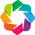

In [2]:
import patpy
import ehrapy as ep
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

Here, I use [COMBAT dataset](https://www.kaggle.com/datasets/shitovvladimir/a-blood-atlas-of-covid-19-combat-preprocessed). It contains PBMC from 140 individuals with various COVID severity. You can find processed dataset, more information about it, and link to the publication on [Kaggle](https://www.kaggle.com/datasets/shitovvladimir/a-blood-atlas-of-covid-19-combat-preprocessed).

In [3]:
adata = sc.read_h5ad("../../data/combat_processed.h5ad")
adata

AnnData object with n_obs × n_vars = 783704 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

In [4]:
sample_key = "scRNASeq_sample_ID"
cell_type_key = "Annotation_major_subset"

The following file contains metadata for donors in COMBAT dataset. It is available on GitHub. We will work with it in ehrapy but note that this is just anndata you are used to in single-cell.

There is a bunch of patient representation methods precalculated. Each of them has distances matrix and UMAP in `obsm`, and donors clustering in `obs`. Think of patient representation as distances between patiens: if a distance is equal to 0, transcriptomics profiles of patients are identical. The bigger the number, the bigger the differences.

In [5]:
#meta_adata = ep.io.read_h5ad("data/combat_meta_adata.h5ad")
meta_adata = sc.read_h5ad("data/combat_meta_adata.h5ad")

Here, we'll focus on the [GloScope](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-024-03398-1) representation obtained on [scPoli](https://www.nature.com/articles/s41592-023-02035-2) cell embeddings. Notably, this method doesn't use any information about patients: neither their clinical status nor even cell type annotation of the data. However, as we'll see, it provides extremely good patient representation.

In [6]:
representation = "gloscope_combat_KL_KNN_25"

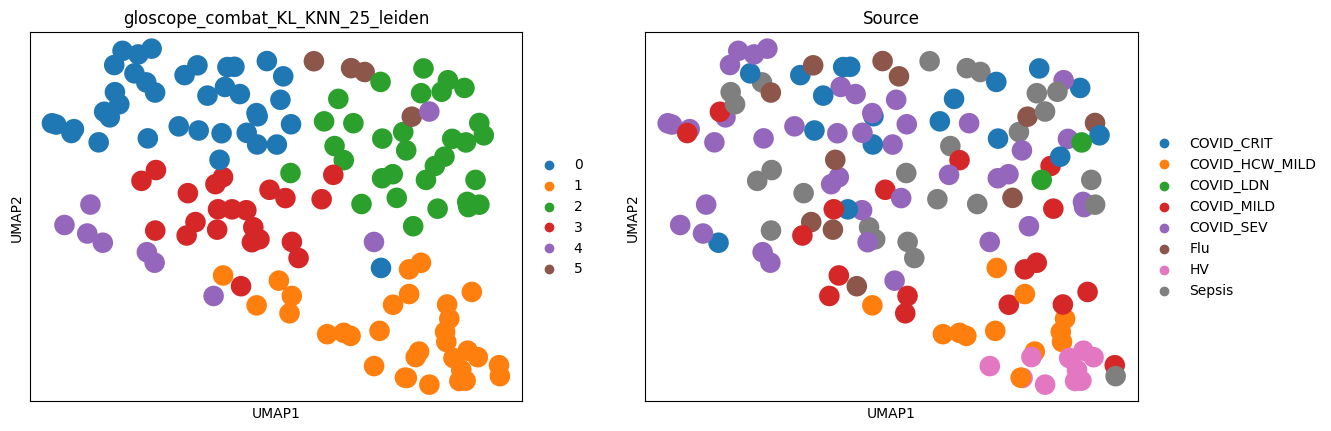

In [7]:
# Set obsm key so that standart umap plotting uses this representation
meta_adata.obsm["umap"] = meta_adata.obsm[f"{representation}_UMAP"]
# Plot UMAP, just like in scanpy. Note that every dot is a donor here!
ep.pl.umap(meta_adata, color=[f"{representation}_leiden", "Source"])

Let's rename some of the columns for a better readability:

In [8]:
meta_adata.obs["Source"] = meta_adata.obs["Source"].map(
    {
        "HV": "Healthy",
        "COVID_MILD": "Mild",
        "COVID_SEV": "Severe",
        "COVID_CRIT": "Critical",
        "COVID_HCW_MILD": "Mild",  # These are healthcare workers with mild disease
        "COVID_LDN": "Critical",
        "Sepsis": "Sepsis",
        "Flu": "Flu",
    }
)

In [9]:
source_palette = {
    "Healthy": "#1f77b4",  # HV
    "Mild": "#ff9999",  # COVID_MILD
    "Severe": "#ff4c4c",  # COVID_SEV
    "Critical": sns.color_palette("Reds")[-1],  # COVID_CRIT
    # "Other": "darkgrey",
    "Sepsis": "#8c564b",  # Sepsis
    "Flu": "#ff7f0e",  # Flu
}

In [10]:
no_box = {
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "xtick.bottom": False,
    "xtick.labelbottom": False,
    "ytick.left": False,
    "ytick.labelleft": False,
}
plot_params = {"figure.figsize": (5, 5), "figure.dpi": 150, "axes.grid": False}
plot_params.update(no_box)

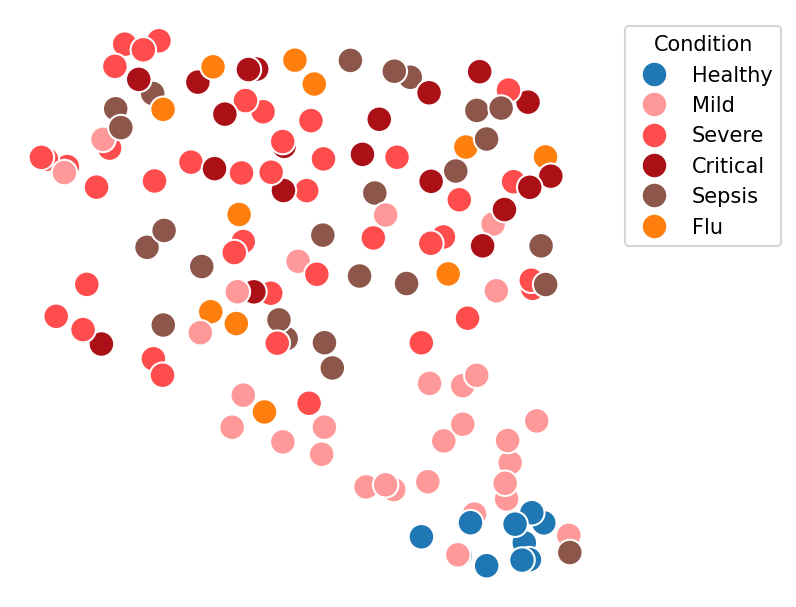

In [11]:
with plt.rc_context(plot_params):
    sns.scatterplot(
        x=meta_adata.obsm[f"{representation}_UMAP"][:, 0],
        y=meta_adata.obsm[f"{representation}_UMAP"][:, 1],
        hue=meta_adata.obs["Source"],
        palette=source_palette,
        hue_order=source_palette.keys(),
        s=150,
    )
    plt.legend(loc=(1.05, 0.6), title="Condition")

Note how all the healthy donors group together, and the severity gradient to the top. This is remarkable because sample representation methods knows nothing about donors condition and only evaluates how similar their transcriptomics profiles are. There are also some mild and even a septic patient grouping together with healthy. Are those errors of the method or misannotations?

With ehrapy, we can apply some single-cell methods to our data. For example, having a sample representation, we can discover trajectories in it via diffusion pseudotime. For this, we need to set the start of trajectory. Let's take a look at the lowest patient on the UMAP:

In [12]:
control_donor_idx = meta_adata.obsm[f"{representation}_UMAP"][:, 1].argmin()
control_donor = meta_adata.obs_names[control_donor_idx]
meta_adata.obs.loc[control_donor, "Source"]

'Healthy'

Some variables are stored in `meta_adata.X` rather then in `.obs`. You can check which ones by running `meta_adata.var_names`

In [13]:
meta_adata[control_donor, ["Age", "Sex", "BMI", "Smoking"]].X

ArrayView([[74.,  0.,  5.,  0.]], dtype=float32)

Ok, so we have a 74-years old non-smoking individual. Perhaps, somebody younger would be a better control but this should be a good start. Also, the dataset has a bit of bias for the older population:

<Axes: ylabel='Count'>

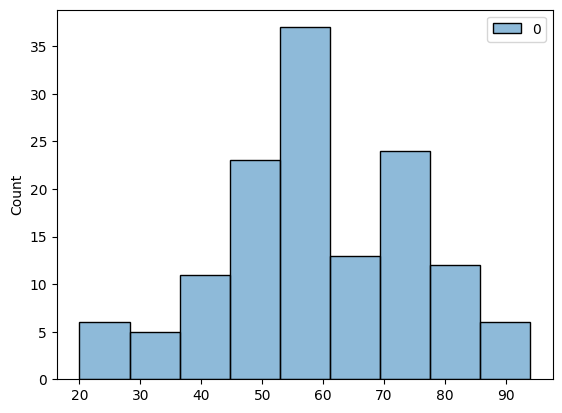

In [14]:
sns.histplot(meta_adata[:, "Age"].X)

Let's set this individual as a root for pseudotime, and run the diffusion:

In [15]:
meta_adata.uns["iroot"] = np.flatnonzero(meta_adata.obs_names == control_donor)[0]
ep.tl.dpt(meta_adata, neighbors_key=f"{representation}_neighbors")

We now have a contunuous score from 0 (for the root we set) to 1 (for a most dissimilar sample), putting every donor on a continuous trajectory

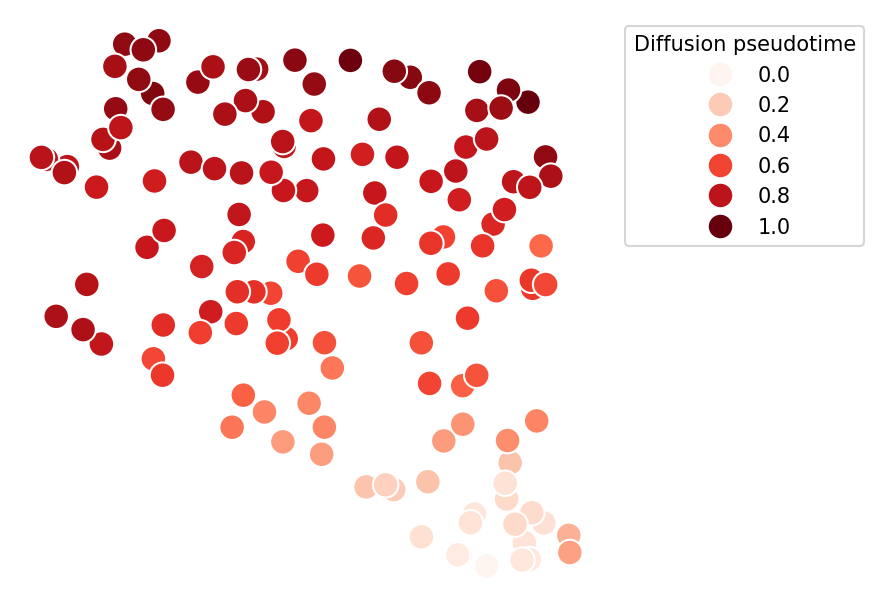

In [16]:
with plt.rc_context(plot_params):
    sns.scatterplot(
        x=meta_adata.obsm[f"{representation}_UMAP"][:, 0],
        y=meta_adata.obsm[f"{representation}_UMAP"][:, 1],
        hue=meta_adata.obs["dpt_pseudotime"],
        s=150,
        palette="Reds",
    )
    plt.legend(loc=(1.05, 0.6), title="Diffusion pseudotime")

But is this score meaningful? Let's take a look at how it corresponds to the severity:

Text(0, 0.5, '')

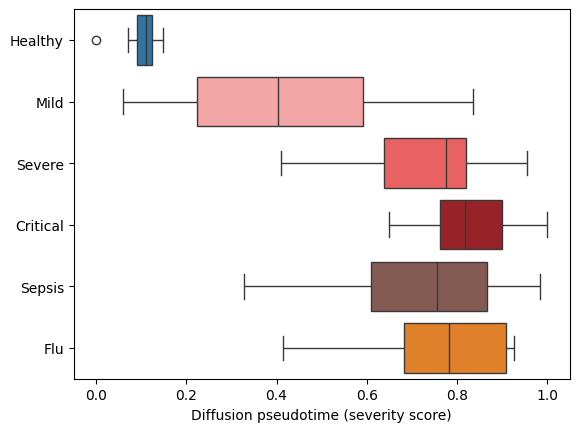

In [17]:
sns.boxplot(
    x=meta_adata.obs["dpt_pseudotime"],
    y=meta_adata.obs["Source"],
    palette=source_palette,
    order=[key for key in source_palette.keys() if key in meta_adata.obs["Source"].unique()],
)
plt.xlabel("Diffusion pseudotime (severity score)")
plt.ylabel("")

We see that higher severity patients have a higher pseudotime score! But instead of a coarse clinical resolution, we now have a continuous trajectory. We now can take a look at what correlates with this trajectory. It could be:
- Cell type proportions
- Gene expression

For the former, let's calculate cell type composition for each patient. You can easily do it with `patpy` package:

In [18]:
cell_type_corrs = patpy.tl.correlate_composition(
    meta_adata=meta_adata,
    expression_adata=adata,
    sample_key=sample_key,
    cell_type_key=cell_type_key,
    target="dpt_pseudotime",
)
cell_type_corrs

,correlation,p_value,p_value_adj,-log_p_value_adj
PB,0.451239,3.131071e-08,5.322821e-07,14.446092
PLT,0.435727,1.028075e-07,5.825759e-07,14.355806
DC,-0.438586,8.293978e-08,5.825759e-07,14.355806
cMono,0.430760,1.485891e-07,6.315037e-07,14.275162
MAIT,-0.422133,2.778327e-07,9.446311e-07,13.872471
HSC,0.339631,4.902797e-05,1.389126e-04,8.881666
NK,-0.333424,6.850823e-05,1.663771e-04,8.701253
iNKT,-0.298163,4.019908e-04,8.542304e-04,7.065310
CD8,-0.291742,5.421241e-04,1.024012e-03,6.884027
DN,-0.238690,4.970933e-03,7.682351e-03,4.868830


Note that in the [COMBAT paper](https://pubmed.ncbi.nlm.nih.gov/35216673/), authors define the following hallmarks of COVID severity:
- Increased level of plasmoblasts (PB), classical monocytes (cMono), platelets (PLT), hemapoetic stem cells (HSCs)
- Decreased levels of dendritic cells (DC), NK cells, T

This is precicely what we see! Interestingly, But for MAIT, our results contradict the paper: they suggest that this cell type should be positively correlated with severity.

But are there particular cell states or gene progrmas that explain COVID? To find them, let's take a look at the average gene expression within each cell type, and correlate it with our severity score

In [19]:
expression_dpt_correlation_df = patpy.tl.correlate_cell_type_expression(
    meta_adata=meta_adata,
    expression_adata=adata,
    sample_key=sample_key,
    cell_type_key=cell_type_key,
    target="dpt_pseudotime",
    layer="X",
    min_sample_size=500,
)

3 samples removed: U00504-Ua005E-PBUa, G05092-Ja005E-PBCa, S00030-Ja003E-PBCa


In [20]:
expression_dpt_correlation_df

,cell_type,gene_name,correlation,p_value,n_observations,p_value_adj,-log_p_value_adj
9151,cMono,S100A8,0.884355,1.671033e-46,137,8.143443e-42,94.611361
11814,cMono,NKG7,0.876631,1.003818e-44,137,2.445953e-40,91.208969
11705,cMono,MCEMP1,0.868571,5.428303e-43,137,8.817916e-39,87.624033
11941,cMono,LGALS1,0.867283,1.002285e-42,137,1.221108e-38,87.298475
10647,cMono,MS4A4A,0.863694,5.352660e-42,137,5.217023e-38,85.846307
...,...,...,...,...,...,...,...
50296,Mast,SNX22,-0.056274,7.200248e-01,43,1.000000e+00,-0.000000
50897,Mast,IGLV2-18,-0.056294,7.199313e-01,43,1.000000e+00,-0.000000
49900,Mast,RACGAP1,-0.058429,7.097652e-01,43,1.000000e+00,-0.000000
50441,Mast,CYB5D2,-0.058816,7.079269e-01,43,1.000000e+00,-0.000000


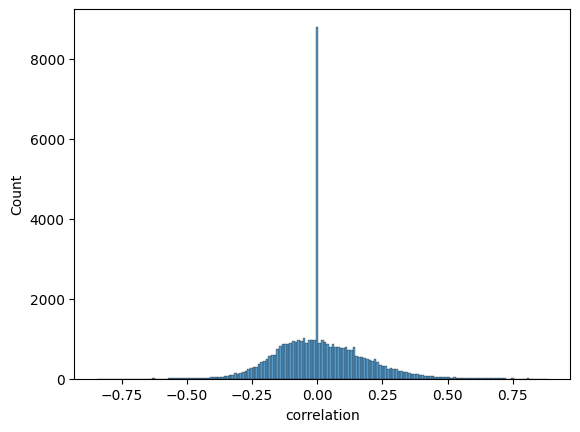

In [21]:
sns.histplot(expression_dpt_correlation_df["correlation"]);

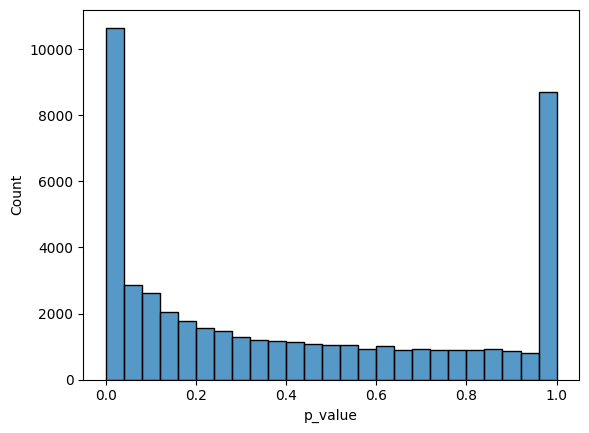

In [22]:
sns.histplot(expression_dpt_correlation_df["p_value"]);

The p-values distribution above is not uniform, and has a peak around 0, which suggests that there are some genes with statistically significant correlation. Let's take a look at top correlated genes:

In [23]:
expression_dpt_correlation_df.head(50)

,cell_type,gene_name,correlation,p_value,n_observations,p_value_adj,-log_p_value_adj
9151,cMono,S100A8,0.884355,1.671033e-46,137,8.143443e-42,94.611361
11814,cMono,NKG7,0.876631,1.003818e-44,137,2.445953e-40,91.208969
11705,cMono,MCEMP1,0.868571,5.428303e-43,137,8.817916e-39,87.624033
11941,cMono,LGALS1,0.867283,1.002285e-42,137,1.221108e-38,87.298475
10647,cMono,MS4A4A,0.863694,5.352660e-42,137,5.217023e-38,85.846307
9763,cMono,SLC39A8,0.849828,2.272493e-39,137,1.845757e-35,79.977589
9149,cMono,S100A9,0.848246,4.359564e-39,137,3.035066e-35,79.480245
10017,cMono,HLA-DMB,-0.844671,1.849540e-38,137,1.126670e-34,78.168627
10529,cMono,ALDH1A1,-0.844298,2.146335e-38,137,1.162193e-34,78.137585
9582,cMono,ACOX2,0.816921,4.524036e-34,137,2.204698e-30,68.286962


This list is largely dominated by classical monocytes. Look at the top correlated gene! In the paper, authors write that S100A8 is a known biomarker, and its expression in cMonocytes correlates with severity. Other markers they mention (`S100A9`, `S100A12`, negative marker `HLA-DRA`) can also be found in the table. Thus, our severity score works

Let's visualize the correlated genes in classical monocytes as they by far dominate in the table. Average expression per sample is now stored in `meta_adata.obsm` in keys `{cell_type}_pseudobulk`. This is controlled by the argument `keep_pseudobulks_in_data` in `patpy.tl.correlate_cell_type_expression`, set it to `False` if you want to save memory

In [24]:
cmono_expression_df = meta_adata.obsm["cMono_pseudobulk"]
cmono_expression_df

,ISG15,TNFRSF18,TNFRSF4,TAS1R3,PRDM16,SMIM1,ACOT7,TNFRSF9,ENO1,SLC2A5,...,MT-CO1,MT-CO2,MT-CO3,MT-ND6,MT-CYB,AC136616.3,AC136616.2,AC141272.1,AC233755.2,AC233755.1
scRNASeq_sample_ID,,,,,,,,,,,,,,,,,,,,,
S00078-Ja003E-PBCa,0.666305,0.001183,0.001026,0.001029,0.0,0.007825,0.001336,0.002106,1.545473,0.005381,...,4.252630,4.054601,3.459366,0.253607,2.783757,0.0,0.0,0.000000,0.008152,0.024226
G05064-Ja005E-PBCa,0.329458,0.000000,0.001716,0.000000,0.0,0.009752,0.006973,0.003692,1.135410,0.001092,...,3.937209,3.933448,3.238184,0.120764,2.759863,0.0,0.0,0.000000,0.008778,0.001008
N00027-Ja001E-PBGa,0.161210,0.000000,0.001394,0.001120,0.0,0.015552,0.001609,0.001727,1.073689,0.002531,...,4.248434,4.193965,3.502021,0.204099,2.744123,0.0,0.0,0.000000,0.012055,0.003364
N00040-Ja001E-PBGa,0.186256,0.000875,0.000637,0.000000,0.0,0.002057,0.023947,0.004306,2.204022,0.001281,...,4.030371,3.831872,3.575325,0.584262,2.572893,0.0,0.0,0.000219,0.005552,0.018434
S00066-Ja001E-PBCa,0.702043,0.000779,0.000201,0.000792,0.0,0.008773,0.008580,0.004020,1.877900,0.004006,...,4.106230,3.834373,3.595163,0.707436,2.959860,0.0,0.0,0.000255,0.012751,0.018012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G05112-Ja005E-PBCa,2.783315,0.000000,0.002990,0.000703,0.0,0.005321,0.004147,0.005504,1.606236,0.005606,...,3.401807,3.298067,2.567472,0.232005,1.962488,0.0,0.0,0.000000,0.008089,0.004275
S00042-Ja001E-PBCa,0.076010,0.000700,0.000000,0.000000,0.0,0.011200,0.007901,0.000000,1.740187,0.000000,...,4.230716,4.037877,3.988372,0.513297,2.790164,0.0,0.0,0.000000,0.008693,0.024193
S00067-Ja001E-PBCa,0.403914,0.000000,0.002425,0.000000,0.0,0.009077,0.005603,0.001093,1.808923,0.005293,...,4.086512,3.805610,3.605104,0.434191,2.720078,0.0,0.0,0.000000,0.032481,0.014675


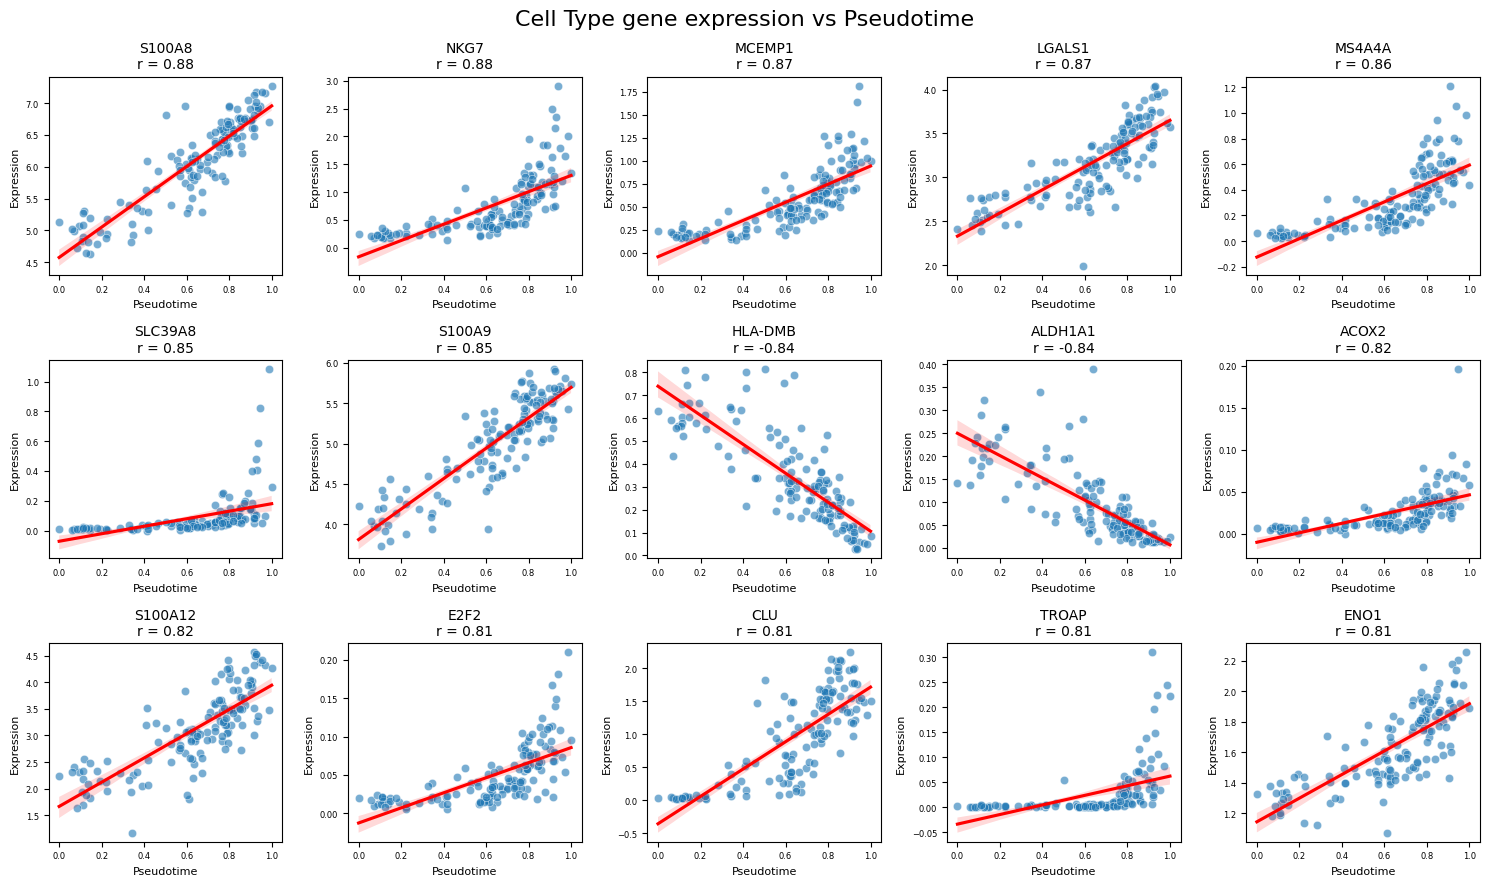

In [25]:
top_genes = expression_dpt_correlation_df.sort_values(["p_value", "correlation"]).head(15)
pseudotime = meta_adata.obs["dpt_pseudotime"]

# Set up the plot
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Cell Type gene expression vs Pseudotime", fontsize=16)

# Flatten the axes array for easier iteration
axes_flat = axes.flatten()

# Plot scatterplots for each significant cell type
for i, (_, row) in enumerate(top_genes.iterrows()):
    ax = axes_flat[i]

    gene_expression = cmono_expression_df.loc[pseudotime.index, row["gene_name"]]
    sns.scatterplot(x=pseudotime, y=gene_expression, ax=ax, alpha=0.6)

    # Add regression line
    sns.regplot(x=pseudotime, y=gene_expression, ax=ax, scatter=False, color="red")

    # Set title with correlation value
    correlation = row["correlation"]
    ax.set_title(f"{row['gene_name']}\nr = {correlation:.2f}", fontsize=10)

    # Set labels
    ax.set_xlabel("Pseudotime", fontsize=8)
    ax.set_ylabel("Expression", fontsize=8)

    # Adjust tick label size
    ax.tick_params(axis="both", which="major", labelsize=6)

# Remove any unused subplots
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

There are certainly non-linear dependencies but S100A8 is a great marker indeed. Let's take a look how it alone explains the severity:

In [26]:
gene_expression = cmono_expression_df.loc[pseudotime.index, "S100A8"]

Text(0, 0.5, '')

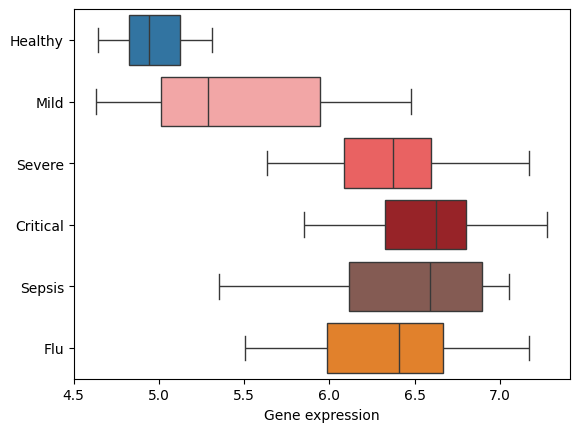

In [27]:
sns.boxplot(
    x=gene_expression.loc[meta_adata.obs_names],
    y=meta_adata.obs["Source"],
    palette=source_palette,
    order=[key for key in source_palette.keys() if key in meta_adata.obs["Source"].unique()],
)
plt.xlabel("Gene expression")
plt.ylabel("")

Well, our score works a bit better but this is definitely a good marker!

We can also visualize results on a volcano plot:

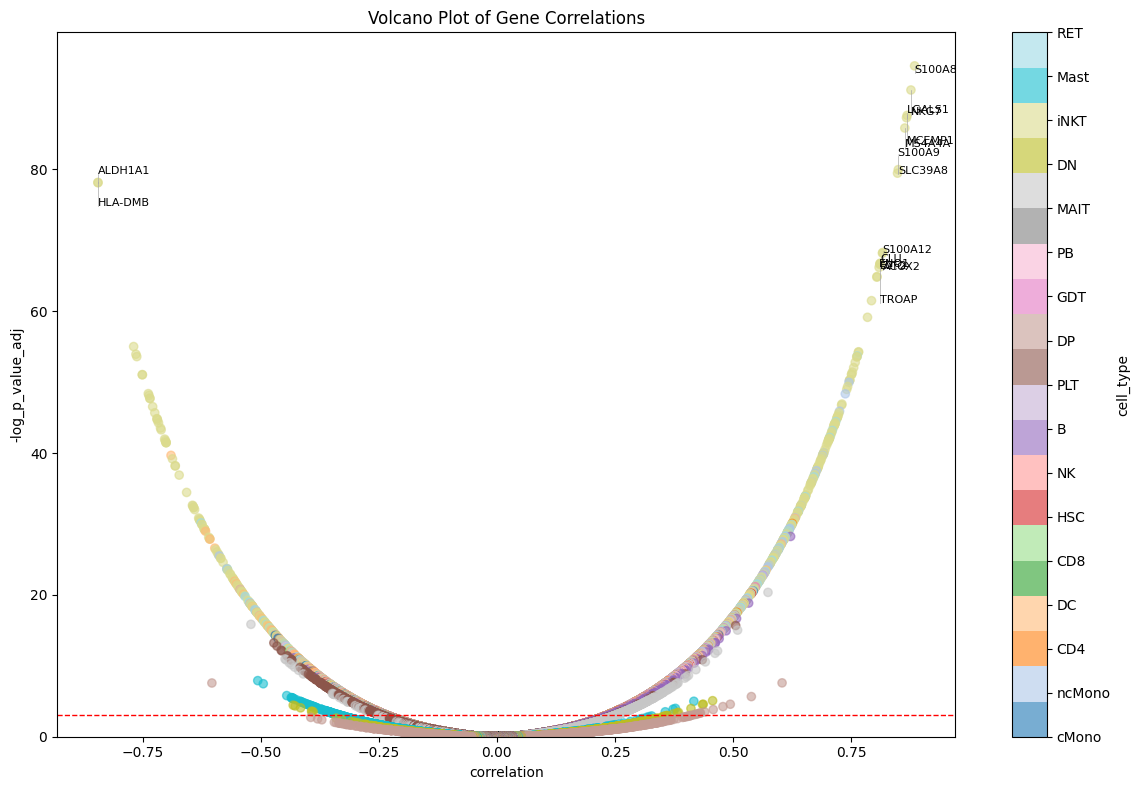

In [28]:
patpy.pl.correlation_volcano(expression_dpt_correlation_df, top_n=15);

## Cell-level analysis

In [29]:
adata.obs['scRNASeq_sample_ID'].unique()

['S00109-Ja001E-PBCa', 'S00112-Ja003E-PBCa', 'S00005-Ja005E-PBCa', 'S00061-Ja003E-PBCa', 'S00056-Ja003E-PBCa', ..., 'S00065-Ja003E-PBCa', 'S00048-Ja003E-PBCa', 'G05112-Ja005E-PBCa', 'N00038-Ja001E-PBGa', 'U00501-Ua005E-PBUa']
Length: 140
Categories (140, object): ['G05061-Ja005E-PBCa', 'G05064-Ja005E-PBCa', 'G05073-Ja005E-PBCa', 'G05077-Ja005E-PBCa', ..., 'U00613-Ua005E-PBUa', 'U00617-Ua005E-PBUa', 'U00619-Ua005E-PBUa', 'U00701-Ua005E-PBUa']

In [30]:
# copy diffusion pseudotime values from the sample representation to the original cell representation
# TODO: is there a builtin patpy method that does this?

adata.obs['dpt_pseudotime'] = adata.obs['scRNASeq_sample_ID'].map(meta_adata.obs['dpt_pseudotime'])
adata.obs['dpt_pseudotime'].head()

AAACCTGAGAAAGTGG-1-gPlexA1    0.849289
AAACCTGAGCGGATCA-1-gPlexA1    0.570235
AAACCTGAGGCGACAT-1-gPlexA1    0.856268
AAACCTGAGGGAACGG-1-gPlexA1    0.840197
AAACCTGCACATGTGT-1-gPlexA1    0.650096
Name: dpt_pseudotime, dtype: float32

In [31]:
adata.obs.groupby('dpt_pseudotime')['scRNASeq_sample_ID'].unique()

dpt_pseudotime
0.000000    ['H00072-Ha001E-PBGa']
Categories (140, object...
0.059860    ['G05097-Ja005E-PBCa']
Categories (140, object...
0.070333    ['H00049-Ha001E-PBGa']
Categories (140, object...
0.085013    ['H00085-Ha001E-PBGa']
Categories (140, object...
0.092045    ['G05061-Ja005E-PBCa']
Categories (140, object...
                                  ...                        
0.945737    ['N00040-Ja001E-PBGa']
Categories (140, object...
0.955070    ['S00119-Ja003E-PBCa']
Categories (140, object...
0.970024    ['S00027-Ja003E-PBCa']
Categories (140, object...
0.985410    ['N00017-Ja003E-PBGa']
Categories (140, object...
1.000000    ['S00040-Ja005E-PBCa']
Categories (140, object...
Name: scRNASeq_sample_ID, Length: 137, dtype: object

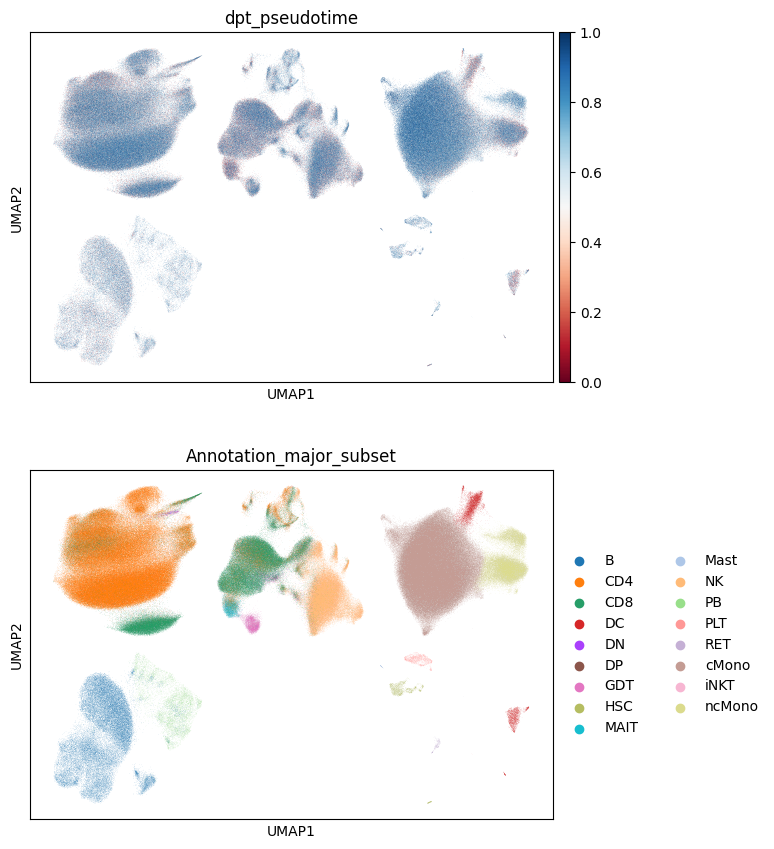

In [32]:
sc.pl.umap(
    adata,
    color=['dpt_pseudotime', cell_type_key],
    cmap='RdBu',
    ncols=1
)

In [33]:
adata.obs["Source"] = adata.obs["Source"].map(
    {
        "HV": "Healthy",
        "COVID_MILD": "Mild",
        "COVID_SEV": "Severe",
        "COVID_CRIT": "Critical",
        "COVID_HCW_MILD": "Mild",  # These are healthcare workers with mild disease
        "COVID_LDN": "Critical",
        "Sepsis": "Sepsis",
        "Flu": "Flu",
    }
)

In [34]:
# # subset to particular cell types of interest, recompute umap

subsets = ['PB', 'cMono', 'PLT', 'HSC']
adata_subs = []

for subset in subsets:
    adata_sub = adata[adata.obs[cell_type_key] == subset].copy()
    adata_subs.append(adata_sub)
    sc.pp.neighbors(adata_sub)
    sc.tl.umap(adata_sub)

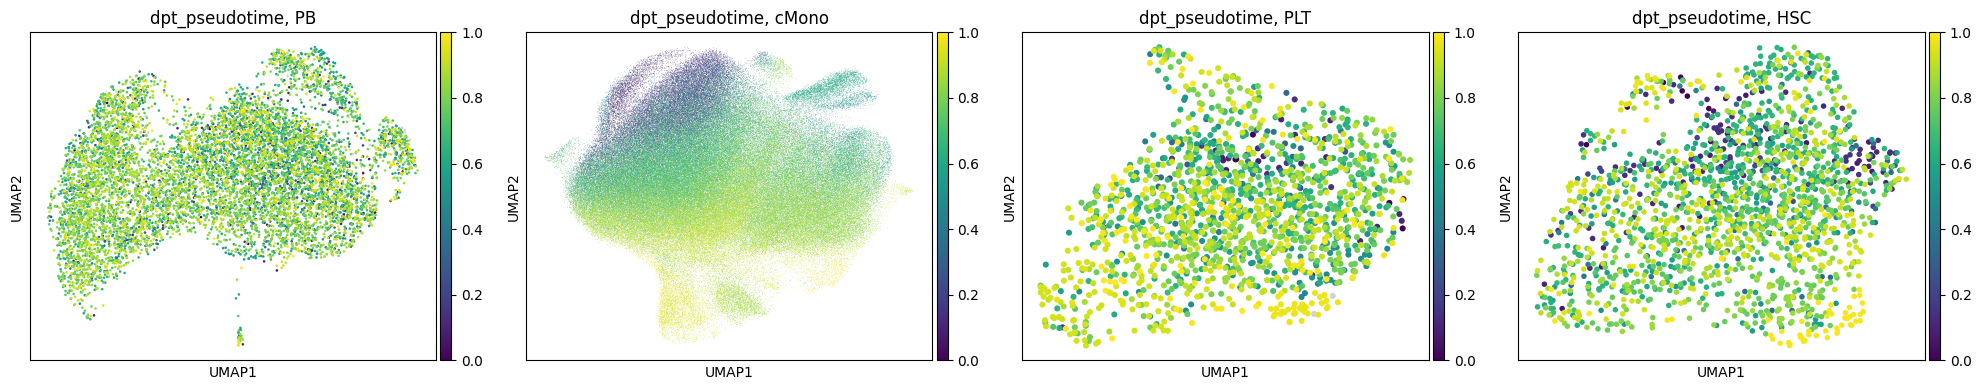

In [37]:
# Create subplots
fig, axes = plt.subplots(1, len(subsets), figsize=(5 * len(subsets), 4))

for ax, adata_sub, idx in zip(axes, adata_subs, list(range(len(adata_subs)))):

    sc.pl.umap(
        adata_sub, 
        color='dpt_pseudotime', 
        ax=ax, 
        show=False, 
        title=f"dpt_pseudotime, {subsets[idx]}",
    )

plt.tight_layout()
plt.show()


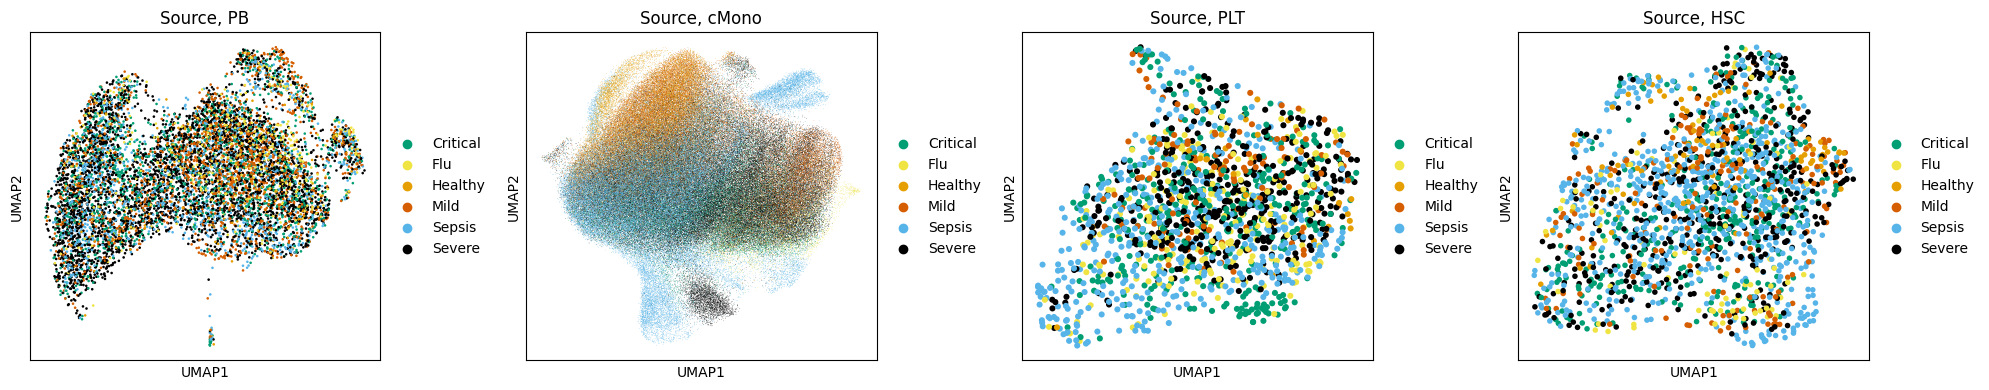

In [38]:
# Create subplots
fig, axes = plt.subplots(1, len(subsets), figsize=(5 * len(subsets), 4))

for ax, adata_sub, idx in zip(axes, adata_subs, list(range(len(adata_subs)))):

    sc.pl.umap(
        adata_sub, 
        color='Source', 
        ax=ax, 
        show=False, 
        title=f"Source, {subsets[idx]}",
    )

plt.tight_layout()
plt.show()

In [39]:
# TODO: clean up the plots, labels, make more like rest of the tutorial

In [45]:
genes = ['CMPK2', 'EPSTI1', 'HERC5', 'IFI35', 'IFI44L', 'IFI6', 'IFIT3', 'ISG15', 'MX1', 'OAS1', 'PLSCR1', 'IRF7']
sc.tl.score_genes(adata, gene_list=genes)

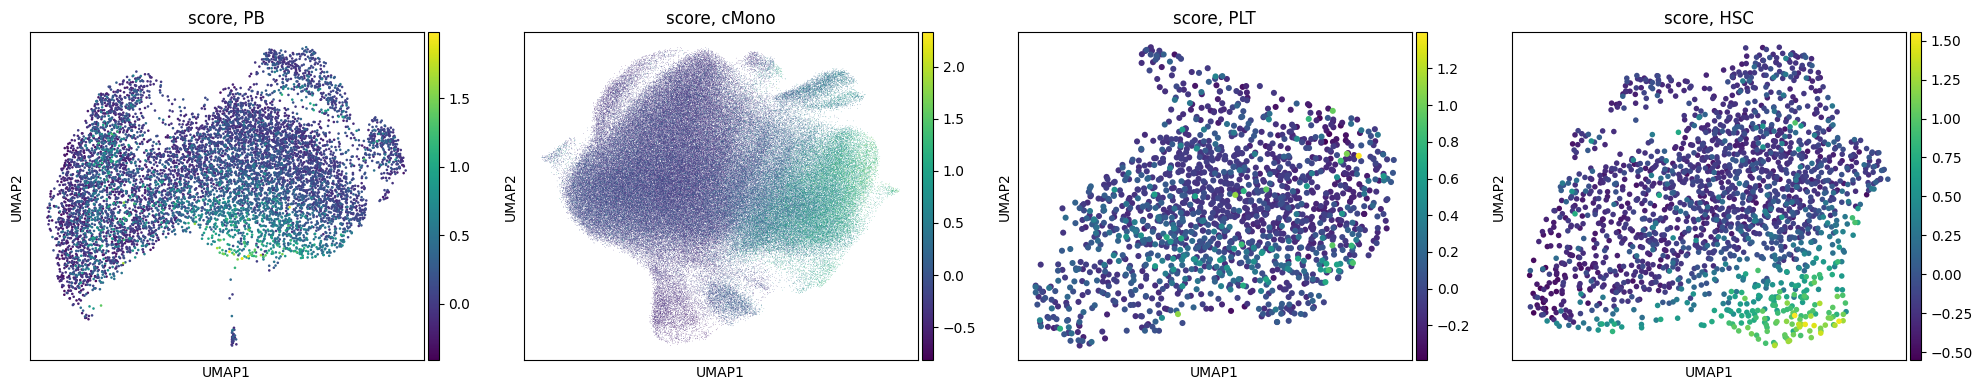

In [46]:
# Create subplots
fig, axes = plt.subplots(1, len(subsets), figsize=(5 * len(subsets), 4))

for ax, adata_sub, idx in zip(axes, adata_subs, list(range(len(adata_subs)))):

    sc.tl.score_genes(adata_sub, gene_list=genes)

    sc.pl.umap(
        adata_sub, 
        color='score', 
        ax=ax, 
        show=False, 
        title=f"score, {subsets[idx]}",
    )

plt.tight_layout()
plt.show()

In [51]:
adata_subs[1]

AnnData object with n_obs × n_vars = 213697 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

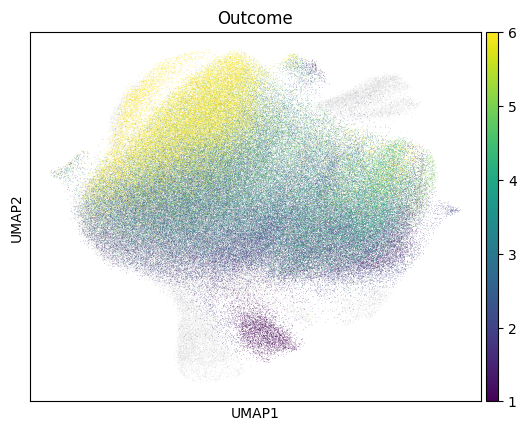

In [52]:
sc.pl.umap(
    adata_subs[1], 
    color='Outcome', 
)

In [ ]:
# TODO: want to compare signature plots above with our pseudotime trajectory, see which correlates better with outcome

In [58]:
meta_adata.obs['Outcome'].value_counts().sum()

np.int64(112)

1 = Death
2 = Intubated, ventilated
3 = Non-invasive ventilation
4 = Hospitalized, O2
5 = Hospitalized, no O2
6 = Not hospitalized

In [61]:
corrs_df = patpy.tl.correlate_cell_type_expression(
    meta_adata=meta_adata,
    expression_adata=adata,
    sample_key=sample_key,
    cell_type_key=cell_type_key,
    target='Outcome',
    layer='X',
    min_sample_size=500,
)
corrs_df

3 samples removed: U00504-Ua005E-PBUa, G05092-Ja005E-PBCa, S00030-Ja003E-PBCa


,cell_type,gene_name,correlation,p_value,n_observations,p_value_adj,-log_p_value_adj
10017,cMono,HLA-DMB,0.780863,3.230868e-24,137,1.574499e-19,43.295180
11705,cMono,MCEMP1,-0.775257,1.097423e-23,137,2.674037e-19,42.765527
10021,cMono,HLA-DPB1,0.772540,1.960345e-23,137,3.184449e-19,42.590837
14582,CD4,NARF,-0.766299,7.211962e-23,137,8.786514e-19,41.575899
9763,cMono,SLC39A8,-0.761057,2.088249e-22,137,2.035333e-18,40.735872
...,...,...,...,...,...,...,...
50449,Mast,DERL2,-0.076026,6.741143e-01,43,1.000000e+00,-0.000000
49538,Mast,NINJ1,-0.076115,6.737555e-01,43,1.000000e+00,-0.000000
48951,Mast,H1-2,-0.076118,6.737428e-01,43,1.000000e+00,-0.000000
49752,Mast,NET1,-0.078166,6.654649e-01,43,1.000000e+00,-0.000000


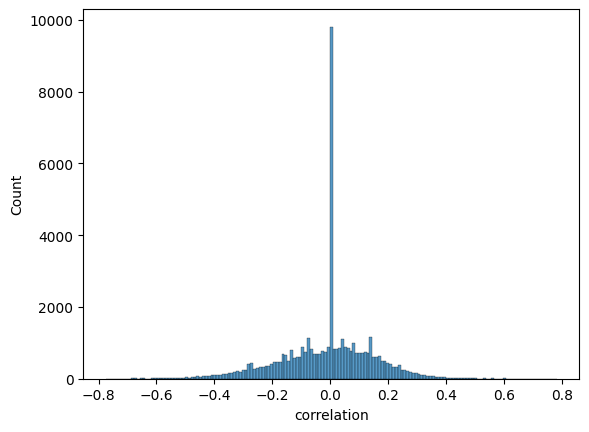

In [63]:
sns.histplot(corrs_df["correlation"]);

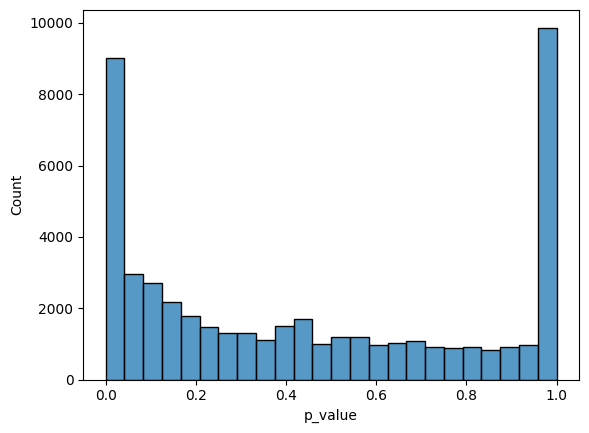

In [62]:
sns.histplot(corrs_df["p_value"]);

In [64]:
subset_df = corrs_df.loc[corrs_df['cell_type'] == 'cMono'] # subset to 
subset_df = subset_df.loc[subset_df['gene_name'].isin(known_genes)]
subset_df

,cell_type,gene_name,correlation,p_value,n_observations,p_value_adj,-log_p_value_adj
9640,cMono,PLSCR1,-0.397231,0.000014,137,0.000605,7.409581
10588,cMono,IRF7,-0.305974,0.001035,137,0.017331,4.055230
10974,cMono,OAS1,-0.269436,0.004069,137,0.046898,3.059778
11515,cMono,IFI35,-0.266718,0.004473,137,0.049908,2.997576
9038,cMono,IFI6,-0.266504,0.004507,137,0.050143,2.992876
9290,cMono,CMPK2,-0.246177,0.008885,137,0.080750,2.516401
11011,cMono,EPSTI1,-0.217422,0.021291,137,0.145421,1.928126
10803,cMono,IFIT3,-0.190284,0.044475,137,0.232929,1.457022
11982,cMono,MX1,-0.179371,0.058442,137,0.274432,1.293051
9000,cMono,ISG15,-0.177048,0.061837,137,0.284641,1.256526


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_title'

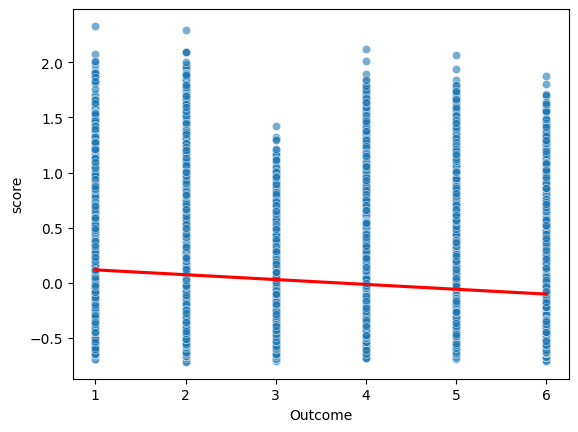

In [ ]:
known_genes = genes
outcome = adata_sub[1].obs['Outcome'] # cMono subset


sns.scatterplot(x=adata_subs[1].obs['Outcome'], y=adata_subs[1].obs['score'], alpha=0.6)
sns.regplot(x=adata_subs[1].obs['Outcome'], y=adata_subs[1].obs['score'], scatter=False, color="red")

coef = np.corrcoef(x=adata_subs[1].obs['Outcome'], y=adata_subs[1].obs['score'])
#plt.set_title(f"{row['gene_name']}\nr = {correlation:.2f}", fontsize=10)



In [ ]:
# Set up the plot
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Cell Type gene expression vs Patient Outcome", fontsize=16)

# Flatten the axes array for easier iteration
axes_flat = axes.flatten()

# Plot scatterplots for each significant cell type
for i, (_, row) in enumerate(top_genes.iterrows()):
    ax = axes_flat[i]

    gene_expression = cmono_expression_df.loc[pseudotime.index, row["gene_name"]]
    sns.scatterplot(x=adata_subs[1].obs['Outcome'], y=adata_subs[1].obs['score'], ax=ax, alpha=0.6)

    # Add regression line
    sns.regplot(x=pseudotime, y=gene_expression, ax=ax, scatter=False, color="red")

    # Set title with correlation value
    correlation = row["correlation"]
    ax.set_title(f"{row['gene_name']}\nr = {correlation:.2f}", fontsize=10)

    # Set labels
    ax.set_xlabel("Pseudotime", fontsize=8)
    ax.set_ylabel("Expression", fontsize=8)

    # Adjust tick label size
    ax.tick_params(axis="both", which="major", labelsize=6)

# Remove any unused subplots
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

In [37]:
adata

AnnData object with n_obs × n_vars = 783704 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

In [ ]:
# TODO: pseudotime on cell level

# find youngest healthy donor

# choose one of their cells as starting cell for pseudotime

# 

In summary, we have seen an example of sample-level analysis that allowed us to obtain a continuous severity score, find potential errors in the original clinical annotation, and easily rediscover known markers. Applying such methods to less explored areas might help you discover something new. With `ehrapy` and `patpy` it only requires running a few lines of code